# Project Introduction

## 1. Canvas Project number: 100

## 2. Group members' names:
Kaiyuan Huang, Gefei Shen, Krystal Qiu, Jiangqi Wu, and Tom Tan

## 3. Data Description
Our dataset combines financial news headlines with stock market data. Each sample includes a news title, date, stock ticker, URL, 10-day historical OHLCV features, 1-day forward OHLCV values, and sector and industry information. The data covers U.S. equities across multiple sectors over the period from July 2010 to June 2020.

## 4. Project Motivation
Financial market news can affect short-term stock price movements and volatility. Accurate volatility forecasting is important for areas such as options pricing, hedging, and risk management. Traditional approaches often rely only on historical price data, but market news may provide additional information about future market behavior. In this project, we study whether combining text data from financial headlines with numeric stock features can improve short-term volatility prediction.

## 5. Summary of the Data + Data Analysis + Meaningful Insights
The final dataset contains a large number of news-stock observations across more than two thousand equity tickers and multiple sectors. For each sample, we aligned the news headline with the corresponding stock and attached both historical market features and next-day market outcomes. This structure allows us to study both text-based and price-based signals for volatility forecasting.

We performed exploratory data analysis to understand the structure of the dataset and the relationship between news and volatility. Key findings include:

* Volatility shows clear persistence over time, meaning high-volatility periods are often followed by continued instability
* Volatility differs across sectors, suggesting that sector information is important
* Strong recent price movements are associated with higher future volatility
* News volume alone does not show a clear relationship with volatility
* Simple headline sentiment is also a weak signal for future volatility
* These results suggest that price-based features provide a strong baseline, while text features may add value only when deeper semantic information is captured

## 6. Clean and Labeled Visualizations
The notebook includes clearly labeled visualizations to support the analysis, such as:

* Volatility over time

*   Volatility by sector
*   Next-day volatility by price trend
* Lagged volatility relationship
* News volume vs. market volatility
* Headline emotional intensity vs. future volatility

These visualizations are used to explain important patterns in the data and motivate the modeling choices.

## 7. Summary of Findings based on Data
Overall, our analysis shows that short-term stock volatility is strongly related to past market behavior, especially recent volatility and price trends. In contrast, simple text features such as headline count and sentiment intensity show limited predictive power on their own. This suggests that a multimodal approach may still be useful, but text data likely needs richer representations, such as financial language embeddings, to provide meaningful improvement over strong numeric baselines.

## 8. Clear Research Question
Can financial news headlines, when combined with recent stock market data, improve the prediction of short-term stock volatility?

#Part 0: Mounting to google drive for using colab

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

import sys, os
sys.path.insert(0, "/content/drive/MyDrive/cs209b/")

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

Mounted at /content/drive


In [ ]:
from pathlib import Path

# ── Configure all paths here ──
ROOT      = Path("/content/drive/MyDrive/cs209b/")
ORIG_DIR  = ROOT / "MS2" / "original_data"   # raw CSVs live here
DATA_DIR  = ROOT / "MS2" / "data"             # outputs go here
OHLCV_DIR = ORIG_DIR / "local_ohlcv_10y_full" # per-ticker OHLCV cache

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OHLCV_DIR, exist_ok=True)

print(f"ROOT      : {ROOT}")
print(f"ORIG_DIR  : {ORIG_DIR}")
print(f"DATA_DIR  : {DATA_DIR}")
print(f"OHLCV_DIR : {OHLCV_DIR}")

ROOT      : /content/drive/MyDrive/cs209b
ORIG_DIR  : /content/drive/MyDrive/cs209b/MS2/original_data
DATA_DIR  : /content/drive/MyDrive/cs209b/MS2/data
OHLCV_DIR : /content/drive/MyDrive/cs209b/MS2/original_data/local_ohlcv_10y_full


# Part 1: Imports

In [ ]:
import datetime as dt
import re
import time
from contextlib import redirect_stderr, redirect_stdout
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import yfinance.shared as yf_shared

import matplotlib.pyplot as plt
import seaborn as sns

# OHLCV field names used throughout
FIELDS = ["Open", "High", "Low", "Close", "Volume"]

# Part 2: Utility Fuctions

## 2.1: Make OHLCV columns

In [ ]:
def make_feature_columns() -> List[str]:
    """Generate the 55 feature-column names: t_minus_1..10 x 5 fields + t_plus_1 x 5 fields."""
    cols: List[str] = []
    for i in range(1, 11):
        for f in FIELDS:
            cols.append(f"t_minus_{i}_{f.lower()}")
    for f in FIELDS:
        cols.append(f"t_plus_1_{f.lower()}")
    return cols

## 2.2 Ticker normalization & helpers

In [ ]:
def normalize_query_ticker(ticker: str) -> str:
    """Normalize ticker for yfinance queries (e.g. BRK.B -> BRK-B)."""
    if not isinstance(ticker, str):
        return ""
    return ticker.strip().replace(".", "-").replace("/", "-")


def safe_filename(name: str) -> str:
    """Sanitize a string for use as a filename."""
    return re.sub(r"[^A-Za-z0-9._-]+", "_", name)

## 2.3 URL merging (processed <-> raw)

In [ ]:
def merge_url(processed: pd.DataFrame, raw: pd.DataFrame) -> pd.Series:
    """
    Merge URLs from the raw dataset onto the processed dataset.
    Primary match: same Unnamed: 0 index + title/headline + stock must agree.
    Fallback: stock + title/headline first non-null url.
    """
    raw_idx = raw[["Unnamed: 0", "headline", "stock", "url"]].rename(
        columns={"stock": "raw_stock", "url": "raw_url"}
    )
    m = processed[["Unnamed: 0", "title", "stock"]].merge(raw_idx, on="Unnamed: 0", how="left")
    valid_primary = (
        m["raw_url"].notna() & (m["stock"] == m["raw_stock"]) & (m["title"] == m["headline"])
    )
    out = m["raw_url"].where(valid_primary)

    lookup = raw[["stock", "headline", "url"]].dropna(subset=["url"]).drop_duplicates(
        ["stock", "headline"], keep="first"
    )
    fallback = processed[["stock", "title"]].merge(
        lookup, left_on=["stock", "title"], right_on=["stock", "headline"], how="left"
    )
    out = out.fillna(fallback["url"])
    return out

 ## 2.4 Load cached ticker history from CSV

In [ ]:
def load_history_from_cache(cache_file: str) -> pd.DataFrame:
    """Read a single per-ticker CSV cache file and return a DatetimeIndex DataFrame."""
    if not os.path.exists(cache_file):
        return pd.DataFrame(columns=FIELDS)
    df = pd.read_csv(cache_file)
    if df.empty or "Date" not in df.columns:
        return pd.DataFrame(columns=FIELDS)

    idx = pd.to_datetime(df["Date"], errors="coerce").dt.normalize()
    out = pd.DataFrame(index=idx)
    for f in FIELDS:
        out[f] = pd.to_numeric(df[f], errors="coerce").to_numpy() if f in df.columns else np.nan
    out = out[~out.index.isna()]
    out = out[~out.index.duplicated(keep="last")]
    out = out.sort_index()
    return out

## 2.5 Compute OHLCV Feature Windows (t-10 ... t+1)

In [ ]:
def compute_features_from_local(
    processed: pd.DataFrame,
    status_df: pd.DataFrame,
    drop_incomplete_rows: bool = True,
) -> pd.DataFrame:
    """
    For each news row, look up the stock's cached OHLCV and fill in:
      - t_minus_1 ... t_minus_10  (previous 10 trading days)
      - t_plus_1                  (next trading day)
    Returns the processed DataFrame with 55 new feature columns appended.
    """
    feature_cols = make_feature_columns()
    n = len(processed)
    feat = np.full((n, len(feature_cols)), np.nan, dtype=np.float64)

    minus_col = {(i, fi): (i - 1) * len(FIELDS) + fi for i in range(1, 11) for fi in range(len(FIELDS))}
    plus_col  = {fi: 10 * len(FIELDS) + fi for fi in range(len(FIELDS))}

    stock_to_file = (
        status_df.drop_duplicates(["stock"], keep="last")[["stock", "cache_file", "status"]]
        .set_index("stock").to_dict("index")
    )

    keep_mask = np.zeros(n, dtype=bool)
    news_days_all = processed["news_day"].values.astype("datetime64[D]")

    grouped = processed.groupby("stock", sort=False).indices
    total = len(grouped)

    for gi, (stock, idxs) in enumerate(grouped.items(), start=1):
        meta = stock_to_file.get(stock)
        if meta is None or meta.get("status") in {"empty", "rate_limited", "bad_cache"}:
            if gi % 200 == 0 or gi == total:
                print(f"Feature progress: {gi}/{total} stocks", flush=True)
            continue

        hist = load_history_from_cache(meta["cache_file"])
        if hist.empty:
            continue

        idxs_arr  = np.asarray(idxs)
        stock_days = news_days_all[idxs_arr]
        valid_day  = ~np.isnat(stock_days)
        if not np.any(valid_day):
            continue

        row_idxs  = idxs_arr[valid_day]
        news_days = stock_days[valid_day]
        dates   = hist.index.values.astype("datetime64[D]")
        arrays  = [hist[f].to_numpy(dtype=np.float64, copy=False) for f in FIELDS]
        left    = np.searchsorted(dates, news_days, side="left")

        # Previous 10 trading days
        for i in range(1, 11):
            prev_idx = left - i
            ok = prev_idx >= 0
            if not np.any(ok):
                continue
            for fi, arr in enumerate(arrays):
                feat[row_idxs[ok], minus_col[(i, fi)]] = arr[prev_idx[ok]]

        # Next trading day (t+1)
        inb = left < len(dates)
        eq  = np.zeros_like(inb, dtype=bool)
        eq[inb] = dates[left[inb]] == news_days[inb]
        nxt = left + eq.astype(np.int64)
        okn = nxt < len(dates)
        if np.any(okn):
            for fi, arr in enumerate(arrays):
                feat[row_idxs[okn], plus_col[fi]] = arr[nxt[okn]]

        keep_mask[row_idxs] = True

        if gi % 200 == 0 or gi == total:
            print(f"Feature progress: {gi}/{total} stocks", flush=True)

    out = processed.copy()
    out = pd.concat([out, pd.DataFrame(feat, columns=feature_cols)], axis=1)
    out = out[keep_mask]
    if drop_incomplete_rows:
        out = out.dropna(subset=feature_cols)
    out = out.reset_index(drop=True)
    return out

## 2.6: Fetch Quote Type

In [ ]:
def fetch_quote_types(tickers, cache_path):
    """Get yfinance quoteType for each ticker. Uses cache CSV if it exists."""
    cache_path = Path(cache_path)
    if cache_path.exists():
        return pd.read_csv(cache_path)

    records = []
    for i, t in enumerate(tickers):
        try:
            info = yf.Ticker(t).info
            qt = info.get("quoteType", "UNKNOWN")
        except Exception:
            qt = "ERROR"
        records.append({"symbol": t, "quoteType": qt})
        if (i + 1) % 100 == 0:
            print(f"quoteType progress: {i+1}/{len(tickers)}", flush=True)
    result = pd.DataFrame(records)
    result.to_csv(cache_path, index=False)
    return result

## 2.7 Fetch Sector and Industry

In [ ]:
def fetch_ticker_metadata(tickers, cache_path):
    """Get sector & industry for each ticker via yfinance. Uses cache CSV if it exists."""
    cache_path = Path(cache_path)
    if cache_path.exists():
        return pd.read_csv(cache_path)

    records = []
    for i, t in enumerate(tickers):
        try:
            info = yf.Ticker(t).info
            records.append({"symbol": t, "sector": info.get("sector"), "industry": info.get("industry")})
        except Exception:
            records.append({"symbol": t, "sector": None, "industry": None})
        if (i + 1) % 100 == 0:
            print(f"metadata progress: {i+1}/{len(tickers)}", flush=True)
    result = pd.DataFrame(records)
    result.to_csv(cache_path, index=False)
    return result

## 2.8 Fetch Earning Report

In [ ]:
import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

def fetch_earnings_all(tickers, cache_path):
    """Fetch earnings dates for all tickers via yf.Ticker().get_earnings_dates(). Uses cache."""
    cache_path = Path(cache_path)
    if cache_path.exists():
        return pd.read_csv(cache_path)

    all_rows = []
    for i, t in enumerate(tickers):
        try:
            ed = yf.Ticker(t).get_earnings_dates(limit=60)
            if ed is not None and not ed.empty:
                ed = ed.reset_index()
                ed["symbol"] = t
                ed = ed.rename(columns={"Earnings Date": "earnings_date"})
                all_rows.append(ed)
        except Exception:
            pass
        if (i + 1) % 100 == 0:
            print(f"earnings progress: {i+1}/{len(tickers)}", flush=True)

    result = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    result.to_csv(cache_path, index=False)
    return result

# Part 3: Data Wrangling and Cleaning

We started by cleaning and aligning the news data with stock market data. Each headline was matched with its stock ticker and date, and then combined with the past 10 days of OHLCV features and the next day’s OHLCV values. This allowed us to create both historical numeric inputs and future volatility targets for each sample.

During preprocessing, we removed ETFs and mutual funds so that the dataset only included individual equities. We also added sector and industry information for each stock. After the merge, most important price-based fields were complete. The main remaining missing field was the news URL, but this was not used in our analysis or models, so it was not treated as a major issue.

We did not remove extreme values on purpose. In financial markets, large price changes and volatility spikes are often real events, not errors. Because of that, we kept these observations in the dataset. This is especially important for periods such as COVID-19, where extreme market behavior carries useful information.

Since our main task is volatility prediction rather than classification, data imbalance was not a major concern at this stage. Feature scaling was also not needed during data cleaning or exploratory analysis, although it may be applied later depending on the model.

## 3.1 Load data and url

In [ ]:
# Load the two source CSVs
processed = pd.read_csv(ORIG_DIR / "analyst_ratings_processed.csv",
                        usecols=["Unnamed: 0", "title", "date", "stock"])
raw = pd.read_csv(ORIG_DIR / "raw_analyst_ratings.csv",
                  usecols=["Unnamed: 0", "headline", "url", "stock"])

print(f"Processed rows: {len(processed):,}")
print(f"Raw rows:       {len(raw):,}")

Processed rows: 1,400,469
Raw rows:       1,407,328


In [ ]:
# Merge URLs from raw onto processed
processed["url"] = merge_url(processed, raw)
print(f"URL coverage: {processed['url'].notna().mean():.2%}")


URL coverage: 93.31%


In [ ]:
# Parse news timestamps -> calendar date (ET)
news_ts = pd.to_datetime(processed["date"], utc=True, errors="coerce")
processed["news_day"] = (
    news_ts.dt.tz_convert("America/New_York")
          .dt.tz_localize(None)
          .dt.normalize()
)
print(f"Date range: {processed['news_day'].min()} to {processed['news_day'].max()}")

Date range: 2009-02-14 00:00:00 to 2020-06-11 00:00:00


## 3.2 Preprocess OHLCV files

In [ ]:
# Build a status DataFrame from the pre-existing OHLCV cache directory.
# This replaces the download step — we just scan what's already on disk.

cache_dir = str(OHLCV_DIR)
stocks = sorted(processed["stock"].dropna().astype(str).unique().tolist())

rows = []
for s in stocks:
    q = normalize_query_ticker(s)
    if not q:
        continue
    fname = safe_filename(q) + ".csv"
    fpath = os.path.join(cache_dir, fname)
    if os.path.exists(fpath):
        rows.append({"stock": s, "query_ticker": q, "cache_file": fpath, "status": "cached", "rows": -1, "message": ""})
    else:
        rows.append({"stock": s, "query_ticker": q, "cache_file": fpath, "status": "missing", "rows": 0, "message": "no_cache_file"})

status_df = pd.DataFrame(rows)
print(f"Total stocks: {len(status_df)}")
print(status_df["status"].value_counts())

Total stocks: 6192
status
cached    6192
Name: count, dtype: int64


## 3.3 Compute features for OHLCV and obtain expanded dataset

In [ ]:
# Compute the 55 OHLCV feature columns from cached data
expanded = compute_features_from_local(
    processed=processed,
    status_df=status_df,
    drop_incomplete_rows=True,
)

# Keep only the final output columns
final_cols = ["title", "date", "stock", "url"] + make_feature_columns()
expanded = expanded[final_cols]
OUTPUT_PATH = DATA_DIR / "analyst_ratings_expanded_local.csv"
expanded.to_csv(OUTPUT_PATH, index=False)

print(f"Output rows : {len(expanded):,}")
print(f"Output cols : {len(expanded.columns)}")
print(f"URL coverage: {expanded['url'].notna().mean():.2%}")

Feature progress: 200/6192 stocks
Feature progress: 400/6192 stocks
Feature progress: 600/6192 stocks
Feature progress: 800/6192 stocks
Feature progress: 1000/6192 stocks
Feature progress: 1200/6192 stocks
Feature progress: 1400/6192 stocks
Feature progress: 1600/6192 stocks
Feature progress: 1800/6192 stocks
Feature progress: 2000/6192 stocks
Feature progress: 2200/6192 stocks
Feature progress: 2400/6192 stocks
Feature progress: 2600/6192 stocks
Feature progress: 2800/6192 stocks
Feature progress: 3000/6192 stocks
Feature progress: 3200/6192 stocks
Feature progress: 3400/6192 stocks
Feature progress: 3600/6192 stocks
Feature progress: 3800/6192 stocks
Feature progress: 4000/6192 stocks
Feature progress: 4200/6192 stocks
Feature progress: 4400/6192 stocks
Feature progress: 4600/6192 stocks
Feature progress: 4800/6192 stocks
Feature progress: 5000/6192 stocks
Feature progress: 5200/6192 stocks
Feature progress: 5400/6192 stocks
Feature progress: 5600/6192 stocks
Feature progress: 5800/6

In [ ]:
expanded.head()

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_open,t_minus_10_high,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.820000,91.739998,89.820000,91.139999,2227500.0,90.650002,...,81.720001,82.190002,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.000000,90.629997,89.110001,90.290001,1682800.0,88.040001,...,83.230003,83.540001,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0
2,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.000000,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.599998,81.989998,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00,A,https://www.benzinga.com/news/20/05/16095921/4...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.669998,80.330002,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00,A,https://www.benzinga.com/news/20/05/16095304/b...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.669998,80.330002,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0


## 3.4: Filter equity only

In [ ]:
tickers = expanded.reset_index()["stock"].unique().tolist() if "stock" not in expanded.columns else expanded["stock"].unique().tolist()

qt = fetch_quote_types(tickers, DATA_DIR / "ticker_quotetype.csv")
print(qt["quoteType"].value_counts())

tickers = expanded.reset_index()["stock"].unique().tolist() if "stock" not in expanded.columns else expanded["stock"].unique().tolist()
qt = fetch_quote_types(tickers, DATA_DIR / "ticker_quotetype.csv")
print(qt["quoteType"].value_counts())

# Keep only EQUITY rows
equity_tickers = qt.loc[qt["quoteType"] == "EQUITY", "symbol"].tolist()

if "stock" not in expanded.columns:
    expanded = expanded.reset_index()

df_eq = expanded[expanded["stock"].isin(equity_tickers)].reset_index(drop=True)
print(f"Rows before: {len(expanded):,}  after: {len(df_eq):,}  dropped: {len(expanded) - len(df_eq):,}")
print(f"Equity tickers: {df_eq['stock'].nunique():,}")

quoteType
EQUITY        2122
ETF            833
MUTUALFUND     181
Name: count, dtype: int64
quoteType
EQUITY        2122
ETF            833
MUTUALFUND     181
Name: count, dtype: int64
Rows before: 849,709  after: 653,926  dropped: 195,783
Equity tickers: 2,122


## 3.5 Fetch Sector & Industry Metadata

In [ ]:
meta = fetch_ticker_metadata(equity_tickers, DATA_DIR / "ticker_metadata.csv")
print(f"Shape: {meta.shape}")
print(f"\nNull counts:\n{meta.isnull().sum()}")
print(f"\nSector distribution:\n{meta['sector'].value_counts()}")

# Join metadata onto equities dataset & drop rows missing sector/industry
df_eq_meta = df_eq.merge(meta, left_on="stock", right_on="symbol", how="left").drop(columns="symbol")
df_eq_meta = df_eq_meta.dropna(subset=["sector", "industry"]).reset_index(drop=True)

print(f"Final shape: {df_eq_meta.shape}")
nulls = df_eq_meta.isnull().sum()
print(f"\nNull counts (non-zero only):\n{nulls[nulls > 0]}")

# Save enriched equities dataset
df_eq_meta.to_csv(DATA_DIR / "expanded_equities.csv", index=False)
df_eq_meta.to_parquet(DATA_DIR / "expanded_equities.parquet", index=False)
print("Saved expanded_equities.csv and .parquet")

Shape: (2122, 3)

Null counts:
symbol       0
sector      14
industry    14
dtype: int64

Sector distribution:
sector
Financial Services        596
Industrials               270
Technology                246
Healthcare                231
Consumer Cyclical         199
Basic Materials           114
Energy                    112
Real Estate               107
Consumer Defensive         95
Communication Services     83
Utilities                  55
Name: count, dtype: int64
Final shape: (650985, 61)

Null counts (non-zero only):
url    36698
dtype: int64
Saved expanded_equities.csv and .parquet


In [ ]:
df_eq.head()

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_open,t_minus_10_high,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.820000,91.739998,89.820000,91.139999,2227500.0,90.650002,...,81.720001,82.190002,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.000000,90.629997,89.110001,90.290001,1682800.0,88.040001,...,83.230003,83.540001,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0
2,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.000000,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.599998,81.989998,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00,A,https://www.benzinga.com/news/20/05/16095921/4...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.669998,80.330002,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00,A,https://www.benzinga.com/news/20/05/16095304/b...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.669998,80.330002,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0


In [ ]:
expanded

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_open,t_minus_10_high,t_minus_10_low,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.820000,91.739998,89.820000,91.139999,2227500.0,90.650002,...,81.720001,82.190002,80.459999,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.000000,90.629997,89.110001,90.290001,1682800.0,88.040001,...,83.230003,83.540001,81.889999,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0
2,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.000000,87.669998,84.199997,84.980003,5063100.0,81.720001,...,79.599998,81.989998,79.500000,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00,A,https://www.benzinga.com/news/20/05/16095921/4...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.669998,80.330002,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00,A,https://www.benzinga.com/news/20/05/16095304/b...,81.720001,82.190002,80.459999,80.750000,2576500.0,82.980003,...,79.669998,80.330002,79.190002,79.709999,2255000.0,86.230003,86.790001,85.639999,86.129997,3173400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849704,"Zumiez Beats, Reverses Loss - Analyst Blog",2010-08-23 08:20:00-04:00,ZUMZ,https://www.benzinga.com/10/08/438769/zumiez-b...,16.450001,16.469999,15.180000,15.740000,375000.0,16.459999,...,17.190001,17.270000,16.930000,17.150000,319300.0,15.780000,15.780000,14.940000,14.970000,338200.0
849705,Jefferies Reiterates Hold Rating on Zumiez (ZUMZ),2010-08-20 09:58:00-04:00,ZUMZ,https://www.benzinga.com/analyst-ratings/analy...,16.459999,16.910000,15.770000,15.950000,334200.0,16.250000,...,17.290001,17.610001,16.900000,16.969999,251400.0,15.900000,16.629999,15.660000,15.910000,253300.0
849706,Zumiez Beats Earnings Estimates (ZUMZ),2010-08-19 16:13:00-04:00,ZUMZ,https://www.benzinga.com/markets/company-news/...,16.250000,16.709999,16.150000,16.480000,361300.0,16.750000,...,18.270000,18.370001,17.180000,17.360001,321300.0,16.450001,16.469999,15.180000,15.740000,375000.0
849707,Piper Jaffray Overweight On Zumiez (ZUMZ),2010-08-06 12:42:00-04:00,ZUMZ,https://www.benzinga.com/markets/company-news/...,18.270000,18.370001,17.180000,17.360001,321300.0,17.900000,...,18.680000,19.389999,18.250000,19.290001,158800.0,17.190001,17.270000,16.930000,17.150000,319300.0


# Part 4: Earning report (Further study)

In [ ]:
earn = fetch_earnings_all(equity_tickers, DATA_DIR / "earnings_dates.csv")
print(f"Earnings records: {len(earn):,}")
earn.head(5)

Earnings records: 26,141


,earnings_date,EPS Estimate,Reported EPS,Surprise(%),symbol
0,2026-04-30 16:00:00-04:00,NaN,NaN,NaN,ATEC
1,2026-02-24 16:00:00-05:00,-0.14,-0.14,-2.94,ATEC
2,2025-10-30 16:00:00-04:00,-0.16,-0.19,-16.33,ATEC
3,2025-07-31 16:00:00-04:00,-0.19,-0.27,-43.37,ATEC
4,2025-05-01 16:00:00-04:00,-0.24,-0.35,-48.49,ATEC


In [ ]:
# Build stock-centric OHLCV dataset (deduplicated by stock+date)
ohlcv_cols = [c for c in df_eq_meta.columns if c.startswith("t_")]
keep_cols  = ["stock", "date"] + ohlcv_cols + ["sector", "industry"]

stock_ohlcv = (
    df_eq_meta[keep_cols]
    .assign(date=pd.to_datetime(df_eq_meta["date"], utc=True).dt.normalize().dt.tz_localize(None))
    .drop_duplicates(subset=["stock", "date"])
    .sort_values(["stock", "date"])
    .reset_index(drop=True)
)
print(f"Deduplicated stock-OHLCV rows: {stock_ohlcv.shape}")

Deduplicated stock-OHLCV rows: (381047, 59)


In [ ]:
# Normalize earnings date for join
earn_join = earn.copy()
earn_join["date"] = (
    pd.to_datetime(earn_join["earnings_date"], utc=True)
      .dt.normalize()
      .dt.tz_localize(None)
)
earn_join = earn_join.drop(columns="earnings_date")

# Check overlap
earn_keys  = set(zip(earn_join["symbol"], earn_join["date"]))
ohlcv_keys = set(zip(stock_ohlcv["stock"], stock_ohlcv["date"]))
matched    = earn_keys & ohlcv_keys

print(f"Earnings records       : {len(earn_join):,}")
print(f"Matched to OHLCV rows  : {len(matched):,}")
print(f"Match rate             : {len(matched)/len(earn_keys)*100:.1f}%")

Earnings records       : 26,141
Matched to OHLCV rows  : 8,356
Match rate             : 32.1%


In [ ]:
# Inner join earnings onto stock_ohlcv
earning_final = stock_ohlcv.merge(
    earn_join.rename(columns={"symbol": "stock"}),
    on=["stock", "date"],
    how="inner",
)

print(f"Final shape: {earning_final.shape}")
earning_final.head()

Final shape: (8362, 62)


,stock,date,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,t_minus_2_high,t_minus_2_low,...,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry,EPS Estimate,Reported EPS,Surprise(%)
0,ATEC,2012-02-28,24.000000,24.240000,23.400000,23.520000,5500.0,23.280001,24.840000,23.160000,...,24.000000,24.000000,21.840000,22.559999,26592.0,Healthcare,Medical Devices,-0.03,-0.72,-2300.00
1,ATEC,2013-04-30,21.360001,23.040001,21.360001,22.200001,14750.0,21.840000,21.959999,21.360001,...,22.799999,23.280001,21.360001,21.480000,28892.0,Healthcare,Medical Devices,-0.04,-0.18,-347.45
2,ATEC,2013-08-06,27.360001,27.600000,27.000000,27.480000,4733.0,27.480000,27.959999,27.120001,...,26.760000,27.000000,24.360001,26.400000,17858.0,Healthcare,Medical Devices,-0.36,-0.12,66.67
3,ATEC,2013-11-07,23.280001,23.280001,22.320000,22.320000,3325.0,23.040001,23.160000,22.680000,...,21.959999,22.440001,21.120001,22.200001,9692.0,Healthcare,Medical Devices,-0.20,-0.24,-21.20
4,ATEC,2014-03-17,16.799999,17.400000,16.559999,16.680000,95367.0,16.920000,16.920000,16.320000,...,21.120001,21.480000,19.799999,20.400000,183725.0,Healthcare,Medical Devices,-0.18,-0.24,-33.33


In [ ]:
# Save final earnings-joined dataset
earning_final.to_parquet(DATA_DIR / "earnings_ONLY_joint.parquet", index=False)
earning_final.to_csv(DATA_DIR / "earnings_ONLY_joint.csv", index=False)
print("Saved earnings_ONLY_joint.parquet and .csv")
print(f"Final rows: {len(earning_final):,}")

Saved earnings_ONLY_joint.parquet and .csv
Final rows: 8,362


# Part 5: Exploratory Data Analysis (EDA)

In [ ]:
eda_df = pd.read_parquet(DATA_DIR / "expanded_equities.parquet")

In [ ]:
print(f"Shape: {eda_df.shape}")
print(f"\nDate range: {eda_df['date'].min()} to {eda_df['date'].max()}")
print(f"Unique stocks:     {eda_df['stock'].nunique()}")
print(f"Unique sectors:    {eda_df['sector'].nunique()}")
print(f"Unique industries: {eda_df['industry'].nunique()}")
print(f"\nMissing values:")
print(eda_df.isnull().sum()[eda_df.isnull().sum() > 0])
print(f"\nData types:")
print(eda_df.dtypes)
print(f"\nSample headlines:")
print(eda_df['title'].sample(5, random_state=42).values)

Shape: (650985, 61)

Date range: 2010-07-24 11:14:00+00:00 to 2020-06-11 21:11:00+00:00
Unique stocks:     2108
Unique sectors:    11
Unique industries: 144

Missing values:
url    36698
dtype: int64

Data types:
title                           object
date               datetime64[ns, UTC]
stock                           object
url                             object
t_minus_1_open                 float64
                          ...         
t_plus_1_low                   float64
t_plus_1_close                 float64
t_plus_1_volume                float64
sector                          object
industry                        object
Length: 61, dtype: object

Sample headlines:
['FedEx Analysts Look for Beat '
 'Identify Risk Exposure & Consider Puts  08-20-2010'
 'Seanergy Maritime Reports Q3 EPS $(0.29), Revenues $8.626M'
 'Sterne Agee Initiates Coverage on CBI, FLR, FWLT, GVA, JEC, KBR, NOA, URS'
 'Technical Alert: Cisco Systems Revisits Recent Highs']


We start by taking a basic look at the dataset to understand what we are working with.
The dataset has 650,985 rows and 61 columns, covering news headlines from
**2010-07-24 to 2020-06-11**. It includes 2,108 unique stocks across 11 sectors
and 144 industries.

The only column with missing values is `url` (36,698 missing), which is fine
since we don't use URLs for modeling. All OHLCV columns are stored as float64
and are complete.

## 5.1 Calculating Volatility, get the y label

We compute next-day realized volatility as our target variable (y) using the
Garman-Klass estimator, which leverages the full OHLCV bar (Open, High, Low, Close)
from day t+1 to produce a more efficient estimate of volatility than simple
close-to-close returns. The formula is:

$$\sigma^2_{GK} = \frac{1}{2}\left(\ln\frac{H}{L}\right)^2 - (2\ln 2 - 1)\left(\ln\frac{C}{O}\right)^2$$

where H, L, C, O are the next-day High, Low, Close, and Open prices respectively.

In [ ]:
# calculating volatility of t+1
eda_df['gk_volatility'] = (
    0.5 * (np.log(eda_df['t_plus_1_high'] / eda_df['t_plus_1_low'])) ** 2
    - (2 * np.log(2) - 1) * (np.log(eda_df['t_plus_1_close'] / eda_df['t_plus_1_open'])) ** 2)


In [ ]:
eda_df.head(3)

,title,date,stock,url,t_minus_1_open,t_minus_1_high,t_minus_1_low,t_minus_1_close,t_minus_1_volume,t_minus_2_open,...,t_minus_10_close,t_minus_10_volume,t_plus_1_open,t_plus_1_high,t_plus_1_low,t_plus_1_close,t_plus_1_volume,sector,industry,gk_volatility
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:00+00:00,A,https://www.benzinga.com/news/20/06/16190091/s...,89.82,91.739998,89.820000,91.139999,2227500.0,90.650002,...,80.750000,2576500.0,89.309998,90.589996,89.059998,90.290001,1804700.0,Healthcare,Diagnostics & Research,0.000099
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:00+00:00,A,https://www.benzinga.com/news/20/06/16170189/s...,90.00,90.629997,89.110001,90.290001,1682800.0,88.040001,...,81.970001,2099200.0,89.820000,91.739998,89.820000,91.139999,2227500.0,Healthcare,Diagnostics & Research,0.000141
2,71 Biggest Movers From Friday,2020-05-26 08:30:00+00:00,A,https://www.benzinga.com/news/20/05/16103463/7...,85.00,87.669998,84.199997,84.980003,5063100.0,81.720001,...,81.269997,1691600.0,86.300003,86.480003,84.370003,86.180000,1917600.0,Healthcare,Diagnostics & Research,0.000304


## 5.2 Volatility Over time
We first check how volatility changes over time across our dataset. This helps us
understand whether the data contains any major market events, and also informs
how we should split our data for training and testing later.

In [ ]:
print(f"Earliest date: {eda_df['date'].min()}")
print(f"Latest date:   {eda_df['date'].max()}")

Earliest date: 2010-07-24 11:14:00+00:00
Latest date:   2020-06-11 21:11:00+00:00


/tmp/ipykernel_13087/3639999101.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  eda_df['month'] = eda_df['date'].dt.to_period('M')


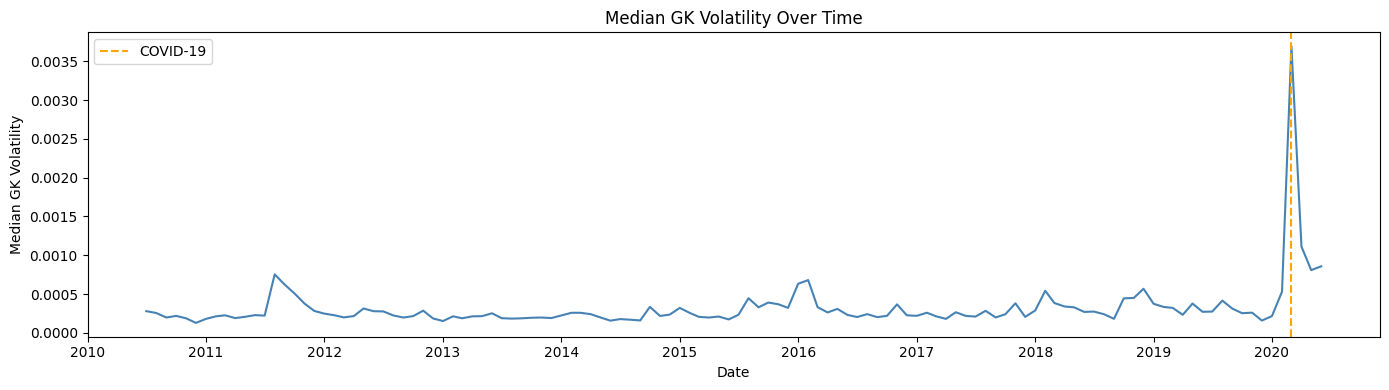

In [ ]:
eda_df['date'] = pd.to_datetime(eda_df['date'])
eda_df['year'] = eda_df['date'].dt.year
eda_df['month'] = eda_df['date'].dt.to_period('M')

monthly_vol = eda_df.groupby('month')['gk_volatility'].median().reset_index()
monthly_vol['month'] = monthly_vol['month'].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(monthly_vol['month'], monthly_vol['gk_volatility'], color='steelblue')
plt.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', label='COVID-19')
plt.title('Median GK Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Median GK Volatility')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The dataset spans from 2010 to 2020 and shows that median GK volatility remains relatively stable from 2010 to 2019, generally staying within a low range with only minor fluctuations. In March 2020, there is a sharp spike to around 0.0035, roughly 7 times the typical baseline, reflecting **the impact of the COVID-19 shock**. However, this increase is short-lived, as volatility quickly declines afterward, suggesting a temporary shock rather than a persistent regime shift and indicating mean-reverting behavior in market volatility.


Since this is time series data, we should split the dataset chronologically rather than randomly to avoid look-ahead bias. For example, we can train on earlier years and test on later periods. Additionally, given the structural break during COVID-19, it may be useful to evaluate model performance separately on pre-COVID and crisis periods to better understand robustness under different market conditions.

## 5.3 Volatility by Sector
We look at whether different sectors tend to have different levels of volatility.
If sector is a strong signal, it means our model should be able to learn
sector-specific patterns.

/tmp/ipykernel_13087/18896225.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_vol, x='sector', y='gk_volatility', palette='coolwarm')


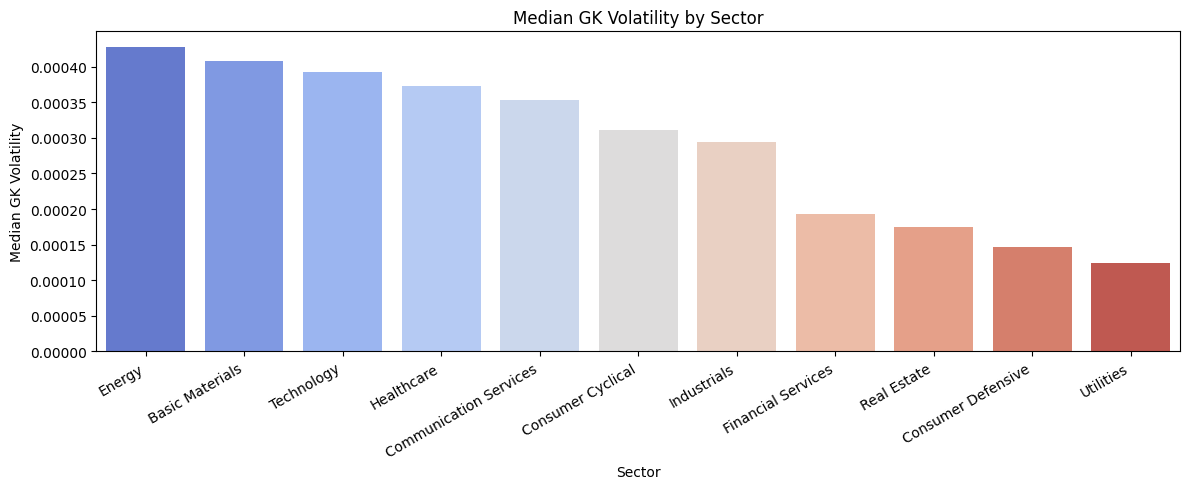

In [ ]:
sector_vol = (eda_df.groupby('sector')['gk_volatility']
              .median()
              .sort_values(ascending=False)
              .reset_index())

plt.figure(figsize=(12, 5))
sns.barplot(data=sector_vol, x='sector', y='gk_volatility', palette='coolwarm')
plt.title('Median GK Volatility by Sector')
plt.xlabel('Sector')
plt.ylabel('Median GK Volatility')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** From the chart, we can see that volatility shows noticeable variation across sectors. Energy and Basic Materials have the highest median volatility, which is reasonable given their exposure to commodity prices and macroeconomic factors. Technology and Healthcare are also relatively high, potentially reflecting sensitivity to firm-specific and innovation-related news. In contrast, Utilities and Consumer Defensive exhibit the lowest volatility, consistent with their defensive nature.

This suggests that sector may be a useful feature for predicting volatility, although further analysis would be needed to confirm its predictive power.

## 5.4 Price Trend vs Next-day Volatility
We check whether the direction of the stock price over the past 10 days
is related to next-day volatility. We compute the 10-day price return as
(t-1 close - t-10 close) / t-10 close, and categorize it into five groups:
- Strong Down (< -5%),
- Slight Down (-5% to -1%)
- Flat (-1% to 1%)
- Slight Up (1% to 5%)
- Strong Up (> 5%).

/tmp/ipykernel_13087/1496360142.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend_vol = eda_df.groupby('trend_direction')['gk_volatility'].median()


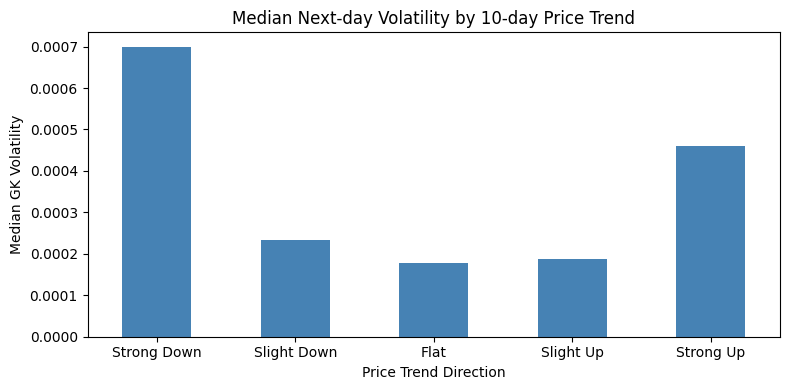

trend_direction
Strong Down    0.000699
Slight Down    0.000235
Flat           0.000179
Slight Up      0.000187
Strong Up      0.000459
Name: gk_volatility, dtype: float64


In [ ]:

# Compute average close price over 10 lookback days
close_cols = [f't_minus_{i}_close' for i in range(1, 11)]
eda_df['avg_close'] = eda_df[close_cols].mean(axis=1)

# Compute price trend: t-1 close vs t-10 close (positive = uptrend)
eda_df['price_trend'] = (eda_df['t_minus_1_close'] - eda_df['t_minus_10_close']) / eda_df['t_minus_10_close']

# Bin trend into direction
eda_df['trend_direction'] = pd.cut(eda_df['price_trend'],
                                    bins=[-np.inf, -0.05, -0.01, 0.01, 0.05, np.inf],
                                    labels=['Strong Down', 'Slight Down', 'Flat', 'Slight Up', 'Strong Up'])

trend_vol = eda_df.groupby('trend_direction')['gk_volatility'].median()

plt.figure(figsize=(8, 4))
trend_vol.plot(kind='bar', color='steelblue', edgecolor='none')
plt.title('Median Next-day Volatility by 10-day Price Trend')
plt.xlabel('Price Trend Direction')
plt.ylabel('Median GK Volatility')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(trend_vol)

**Interpretation:** The chart shows a roughly U-shaped pattern, where stocks experiencing strong price movements in either direction over the past 10 days tend to have higher next-day volatility, while flat stocks exhibit the lowest volatility. Notably, the effect is asymmetric, with Strong Down showing the highest volatility (0.000699), significantly higher than both Flat (0.000179) and Strong Up (0.000459).

This suggests that large recent price movements, especially on the downside, are associated with increased future volatility, potentially reflecting higher market uncertainty. Overall, this indicates that recent price trends may contain useful predictive signal, supporting the inclusion of OHLCV-based features in the model.

## 5.5 TF-IDF Analysis: High vs Low Volatility Headlines

We use TF-IDF to identify which words are most associated with high vs low
next-day volatility. Headlines are split into two groups based on the 75th
percentile of GK volatility (threshold = 0.000863) — the top 25% are labeled
as high volatility and the rest as low volatility. We then compare the average
TF-IDF scores between the two groups to find words that distinctly characterize
each group.

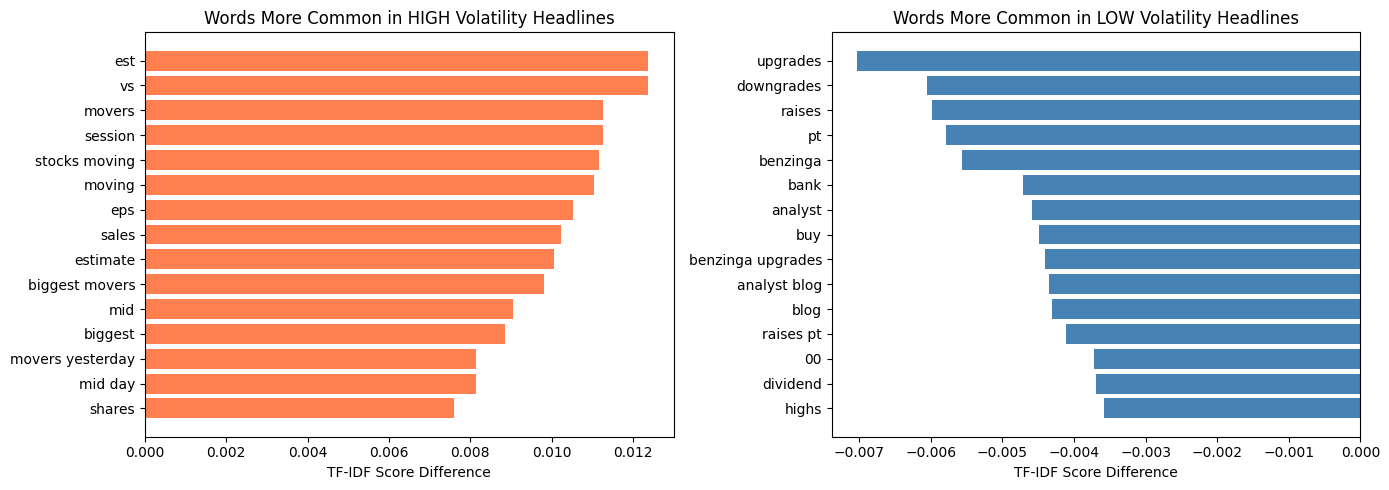

In [ ]:


from sklearn.feature_extraction.text import TfidfVectorizer

# Split into high and low volatility
threshold = eda_df['gk_volatility'].quantile(0.75)
high_vol_titles = eda_df[eda_df['gk_volatility'] >= threshold]['title'].fillna('')
low_vol_titles  = eda_df[eda_df['gk_volatility'] <  threshold]['title'].fillna('')

# Fit TF-IDF on all titles
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
vectorizer.fit(eda_df['title'].fillna(''))

# Get mean TF-IDF score per word for each group
high_tfidf = vectorizer.transform(high_vol_titles).mean(axis=0)
low_tfidf  = vectorizer.transform(low_vol_titles).mean(axis=0)

# Convert to dataframe
import numpy as np
features = vectorizer.get_feature_names_out()
high_scores = np.asarray(high_tfidf).flatten()
low_scores  = np.asarray(low_tfidf).flatten()

tfidf_df = pd.DataFrame({
    'word': features,
    'high_vol_score': high_scores,
    'low_vol_score':  low_scores
})

# Words more associated with HIGH volatility
tfidf_df['diff'] = tfidf_df['high_vol_score'] - tfidf_df['low_vol_score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top words for HIGH volatility
top_high = tfidf_df.nlargest(15, 'diff')
axes[0].barh(top_high['word'], top_high['diff'], color='coral')
axes[0].set_title('Words More Common in HIGH Volatility Headlines')
axes[0].set_xlabel('TF-IDF Score Difference')
axes[0].invert_yaxis()

# Top words for LOW volatility
top_low = tfidf_df.nsmallest(15, 'diff')
axes[1].barh(top_low['word'], top_low['diff'], color='steelblue')
axes[1].set_title('Words More Common in LOW Volatility Headlines')
axes[1].set_xlabel('TF-IDF Score Difference')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Interpretation:** The results show noticeable differences in language between high and low volatility headlines. High volatility headlines more frequently include terms like “movers” and “stocks moving,” which often describe stocks experiencing large price changes, as well as earnings-related terms such as “eps,” “estimate,” and “sales.”

In contrast, low volatility headlines are more associated with analyst actions like “upgrades,” “downgrades,” and “raises pt,” along with terms like “dividend” and “highs,” which tend to be linked to more stable price behavior.

Overall, this suggests that the text content of headlines carries meaningful
signal for predicting next-day volatility, which justifies including a text
encoder in our multimodal model.

## 5.6 Relationship Between News Volume and Market Volatility

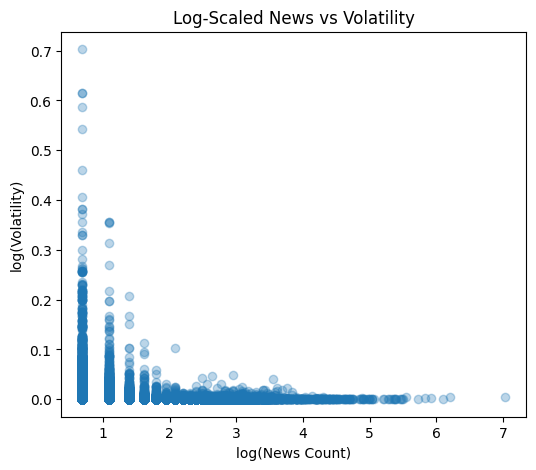

In [ ]:
news_count = eda_df.groupby('date').size()
vol = eda_df.groupby('date')['gk_volatility'].median()

merged = pd.concat([news_count, vol], axis=1)
merged.columns = ['news_count', 'vol']
plt.figure(figsize=(6,5))
plt.scatter(
    np.log1p(merged['news_count']),
    np.log1p(merged['vol']),
    alpha=0.3
)
plt.xlabel("log(News Count)")
plt.ylabel("log(Volatility)")
plt.title("Log-Scaled News vs Volatility")
plt.show()

**Interpretation:** After applying log transformation, no clear positive relationship is observed between news volume and volatility. In fact, high-volatility events often occur on days with relatively low news volume, suggesting that sheer quantity of news may not be a strong driver of market volatility

## 5.7 Headline Emotional Intensity and Future Volatility

We used TextBlob to compute sentiment polarity and subjectivity for each news headline. Then we took the absolute value of polarity as a measure of emotional intensity, where higher values indicate more strongly worded headlines regardless of being positive or negative. We compared this feature with next-day volatility (vol_t_plus_1) using a scatter plot.

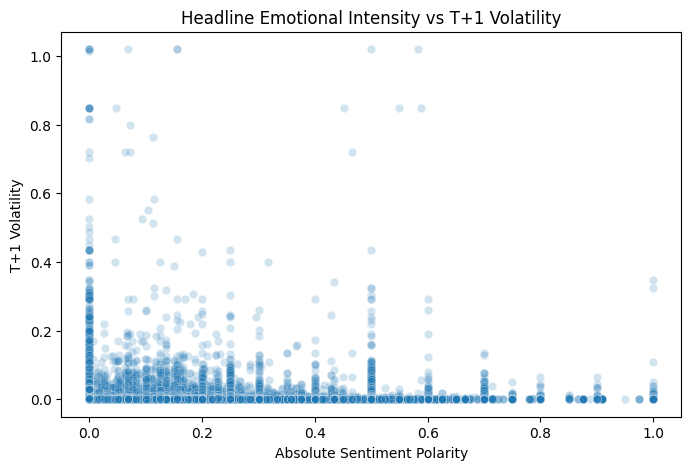

In [ ]:
from textblob import TextBlob


eda_df['sentiment_polarity'] = eda_df['title'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
eda_df['sentiment_subjectivity'] = eda_df['title'].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

eda_df['abs_sentiment'] = eda_df['sentiment_polarity'].abs()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=eda_df, x='abs_sentiment', y='vol_t_plus_1', alpha=0.2)
plt.title('Headline Emotional Intensity vs T+1 Volatility')
plt.xlabel('Absolute Sentiment Polarity')
plt.ylabel('T+1 Volatility')
plt.show()

**Interpretation:** Most headlines are close to neutral, and the plot does not show a clear positive relationship between emotional intensity and next-day volatility. This suggests that simple sentiment strength alone is not a strong predictor of future volatility. In other words, market moves are likely driven more by the specific content of news events than by the emotional tone of the headline itself.